# Self-Adjoint Operators & The Spectral Theorem

## Motivation

Self-adjoint operators are the workhorses of applied mathematics. Wherever symmetry appears — in physics, statistics, geometry, or numerical analysis — self-adjoint operators follow. Their central property, the **spectral theorem**, guarantees a complete orthonormal basis of eigenvectors with real eigenvalues, turning complex operator questions into manageable diagonal form.

| Domain | Self-Adjoint Object | What the Spectral Theorem Gives You |
|--------|--------------------|---------------------------------|
| Statistics | Covariance matrix $\Sigma$ | Principal components (PCA) |
| Quantum Mechanics | Hamiltonian $H$ | Observable energy levels |
| PDEs | Laplacian $-\Delta$ | Normal modes, heat/wave equation solution |
| Graph Theory | Graph Laplacian $L$ | Spectral clustering, connectivity |
| Optimization | Hessian $\nabla^2 f$ | Second-order optimality conditions |
| Numerical LA | Symmetric tridiagonal matrices | Sturm-Liouville eigenproblems |

## Prerequisites

| Topic | Key Concepts |
|-------|--------------|
| Linear algebra | Vector spaces, linear maps, matrix algebra |
| Inner products | Bilinear forms, orthogonality, norms |
| Eigentheory | Eigenvalues, eigenvectors, characteristic polynomial |
| Analysis | Convergence, completeness (for infinite-dimensional sections) |

## References

- Axler, *Linear Algebra Done Right* (3rd ed.) — Chapters 7–9
- Trefethen & Bau, *Numerical Linear Algebra* — Lectures 24–27
- Reed & Simon, *Methods of Modern Mathematical Physics, Vol. I* — Chapter VI
- Brezis, *Functional Analysis, Sobolev Spaces and Partial Differential Equations* — Chapter 6

In [1]:
%matplotlib inline
import numpy as np
from scipy import linalg as la
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
rng  = np.random.default_rng(SEED)

# ── Tolerances ─────────────────────────────────────────────────────────────────
ATOL = 1e-10
RTOL = 1e-6

# ── Plot Style ─────────────────────────────────────────────────────────────────
PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'mediumpurple'
GRAY      = '#888888'

plt.rcParams.update({
    'figure.figsize'  : (12, 5),
    'font.size'       : 12,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'lines.linewidth' : 2,
    'axes.spines.top' : False,
    'axes.spines.right': False,
})

def check(condition, label):
    """Print a PASS/FAIL verification result."""
    status = 'PASS' if condition else 'FAIL'
    print(f'  [{status}]  {label}')
    return condition

print('Setup complete.')

Setup complete.


---
## 1.  Inner Product Spaces & Hilbert Spaces

### 1.1  Inner Products

An **inner product** on a vector space $V$ over $\mathbb{F}$ ($\mathbb{R}$ or $\mathbb{C}$) is a map $\langle \cdot, \cdot \rangle : V \times V \to \mathbb{F}$ satisfying:

1. **Conjugate symmetry**: $\langle u, v \rangle = \overline{\langle v, u \rangle}$
2. **Linearity in first argument**: $\langle \alpha u + \beta w, v \rangle = \alpha \langle u, v \rangle + \beta \langle w, v \rangle$
3. **Positive definiteness**: $\langle v, v \rangle \geq 0$, with equality iff $v = 0$

The induced **norm** is $\|v\| = \sqrt{\langle v, v \rangle}$.

**Cauchy-Schwarz Inequality:**
$$\boxed{|\langle u, v \rangle| \leq \|u\| \cdot \|v\|}$$
with equality iff $u$ and $v$ are linearly dependent.

### 1.2  Hilbert Spaces

A **Hilbert space** $\mathcal{H}$ is an inner product space that is **complete**: every Cauchy sequence converges in $\mathcal{H}$.

| Example | Inner Product | Hilbert Space? |
|---------|--------------|----------------|
| $\mathbb{R}^n$ | $\langle x, y \rangle = x^\top y$ | Yes (finite-dim) |
| $\mathbb{C}^n$ | $\langle x, y \rangle = x^* y$ | Yes (finite-dim) |
| $L^2([a,b])$ | $\langle f, g \rangle = \int_a^b f(x)\overline{g(x)}\,dx$ | Yes |
| $\ell^2$ | $\langle (a_n), (b_n) \rangle = \sum_n a_n \overline{b_n}$ | Yes |
| $C([0,1])$ with $L^2$ norm | same as $L^2$ | No (not complete) |

### 1.3  Gram-Schmidt Orthogonalization

Given linearly independent vectors $\{v_1, \ldots, v_k\}$, Gram-Schmidt produces an orthonormal set $\{e_1, \ldots, e_k\}$ spanning the same subspace:
$$u_j = v_j - \sum_{i=1}^{j-1} \langle v_j, e_i \rangle \, e_i, \qquad e_j = \frac{u_j}{\|u_j\|}$$

In [2]:
# ── Gram-Schmidt Orthogonalization ─────────────────────────────────────────────

def gram_schmidt(V):
    """Gram-Schmidt orthonormalization (classical, column-wise).

    Args:
        V: Input matrix whose columns are linearly independent vectors.
            Shape: (n, k)

    Returns:
        Q: Matrix with orthonormal columns spanning the same column space as V.
            Shape: (n, k)
    """
    n, k = V.shape
    Q = np.zeros_like(V, dtype=float)
    for j in range(k):
        u = V[:, j].copy().astype(float)
        for i in range(j):
            u -= np.dot(Q[:, i], u) * Q[:, i]   # subtract projection
        norm = np.linalg.norm(u)
        if norm < ATOL:
            raise ValueError(f'Column {j} is linearly dependent on previous columns.')
        Q[:, j] = u / norm
    return Q


def cauchy_schwarz_demo(u, v):
    """Verify the Cauchy-Schwarz inequality for two vectors."""
    lhs = abs(np.dot(u, v))
    rhs = np.linalg.norm(u) * np.linalg.norm(v)
    return lhs, rhs


# ── Demo ────────────────────────────────────────────────────────────────────────
n, k = 6, 4
V = rng.standard_normal((n, k))
Q = gram_schmidt(V)

print('Gram-Schmidt verification (n=6, k=4):')
check(np.allclose(Q.T @ Q, np.eye(k), atol=ATOL), 'Qᵀ Q = I  (orthonormality)')
check(np.linalg.matrix_rank(Q) == k,              'rank(Q) = k  (no collapse)')

# Verify column spaces match
proj_V = V @ np.linalg.pinv(V)   # projector onto col(V)
proj_Q = Q @ Q.T                  # projector onto col(Q)
check(np.allclose(proj_V, proj_Q, atol=1e-8), 'col(V) = col(Q)  (same subspace)')

# Cauchy-Schwarz
u = rng.standard_normal(8)
v = rng.standard_normal(8)
lhs, rhs = cauchy_schwarz_demo(u, v)
print(f'\nCauchy-Schwarz: |⟨u,v⟩| = {lhs:.4f}  ≤  ‖u‖·‖v‖ = {rhs:.4f}')
check(lhs <= rhs + ATOL, 'Cauchy-Schwarz holds')

Gram-Schmidt verification (n=6, k=4):
  [PASS]  Qᵀ Q = I  (orthonormality)
  [PASS]  rank(Q) = k  (no collapse)
  [PASS]  col(V) = col(Q)  (same subspace)

Cauchy-Schwarz: |⟨u,v⟩| = 1.1927  ≤  ‖u‖·‖v‖ = 5.0660
  [PASS]  Cauchy-Schwarz holds


True

---
## 2.  Adjoint Operators

### 2.1  Definition

Let $T : \mathcal{H}_1 \to \mathcal{H}_2$ be a bounded linear operator between Hilbert spaces. The **adjoint** $T^* : \mathcal{H}_2 \to \mathcal{H}_1$ is the unique operator satisfying:
$$\boxed{\langle Tx, y \rangle_{\mathcal{H}_2} = \langle x, T^* y \rangle_{\mathcal{H}_1} \quad \forall\, x \in \mathcal{H}_1,\; y \in \mathcal{H}_2}$$

**Finite-dimensional case**: For $A \in \mathbb{R}^{m \times n}$ with standard inner product, $A^* = A^\top$. For $A \in \mathbb{C}^{m \times n}$, $A^* = \bar{A}^\top$ (conjugate transpose).

### 2.2  Self-Adjoint Operators

An operator $T : \mathcal{H} \to \mathcal{H}$ is **self-adjoint** (or **Hermitian**) if $T = T^*$, i.e.:
$$\langle Tx, y \rangle = \langle x, Ty \rangle \quad \forall\, x, y \in \mathcal{H}$$

In finite dimensions: $A$ is self-adjoint iff $A = A^*$ (i.e., $A_{ij} = \overline{A_{ji}}$). For real matrices, this means $A = A^\top$ (symmetric).

### 2.3  Key Properties (Derived)

**Theorem**: Let $T$ be self-adjoint. Then:

1. **Real eigenvalues**: If $Tv = \lambda v$, then $\lambda \in \mathbb{R}$.
   - *Proof*: $\lambda \|v\|^2 = \langle Tv, v \rangle = \langle v, Tv \rangle = \bar{\lambda}\|v\|^2 \Rightarrow \lambda = \bar{\lambda}$. $\square$

2. **Orthogonal eigenvectors**: Eigenvectors for distinct eigenvalues are orthogonal.
   - *Proof*: Let $Tv = \lambda v$, $Tw = \mu w$, $\lambda \neq \mu$. Then $(\lambda - \mu)\langle v, w \rangle = \langle Tv, w \rangle - \langle v, Tw \rangle = 0$. $\square$

3. **Operator norm is spectral radius**: $\|T\| = \sup_{\|x\|=1} |\langle Tx, x \rangle| = \max_i |\lambda_i|$.

| Operator Type | $A = A^*$? | Eigenvalues | Eigenvector Basis |
|---------------|-----------|-------------|-------------------|
| Symmetric ($A = A^\top$, real) | Yes | Real | Orthonormal |
| Hermitian ($A = A^*$, complex) | Yes | Real | Orthonormal |
| Skew-symmetric ($A = -A^\top$) | No  | Purely imaginary | Orthonormal |
| Normal ($AA^* = A^*A$) | Generalization | Complex | Orthonormal |
| General | No  | Complex | Not necessarily orth. |

In [3]:
# ── Adjoint & Self-Adjointness Utilities ───────────────────────────────────────

def adjoint(A):
    """Compute the adjoint (conjugate transpose) of a matrix.

    Args:
        A: Input matrix.  Shape: (m, n)

    Returns:
        A*: Adjoint matrix.  Shape: (n, m)
    """
    return np.conj(A).T


def is_self_adjoint(A, tol=ATOL):
    """Check whether A equals its adjoint."""
    return np.allclose(A, adjoint(A), atol=tol)


def make_self_adjoint(n, rng=rng):
    """Construct a random real symmetric n×n matrix."""
    B = rng.standard_normal((n, n))
    return (B + B.T) / 2


def verify_eigenvalue_reality(A):
    """Show eigenvalues of a self-adjoint matrix are real."""
    vals = np.linalg.eigvals(A)          # general eigensolver (may return complex)
    max_imag = np.max(np.abs(vals.imag))
    return vals.real, max_imag


def verify_eigenvector_orthogonality(A):
    """Compute max off-diagonal entry of VᵀV where V are eigenvectors."""
    _, V = np.linalg.eigh(A)             # eigh exploits symmetry
    gram = V.T @ V
    off_diag = gram - np.diag(np.diag(gram))
    return np.max(np.abs(off_diag))


# ── Demo ────────────────────────────────────────────────────────────────────────
A_sym  = make_self_adjoint(5)
A_asym = rng.standard_normal((5, 5))       # generic, not symmetric

print('Self-adjointness checks:')
check(is_self_adjoint(A_sym),  'Random symmetric matrix: A = Aᵀ')
check(not is_self_adjoint(A_asym), 'Random general matrix: A ≠ Aᵀ  (expected)')

# Real eigenvalues for symmetric matrix
vals_real, max_imag = verify_eigenvalue_reality(A_sym)
print(f'\nEigenvalues of symmetric 5×5:')
print(f'  Values (real parts): {np.round(vals_real, 4)}')
check(max_imag < ATOL, f'All eigenvalues real  (max |Im| = {max_imag:.2e})')

# Orthogonal eigenvectors
max_off = verify_eigenvector_orthogonality(A_sym)
check(max_off < ATOL, f'Eigenvectors orthonormal  (max off-diag = {max_off:.2e})')

# Complex Hermitian example
B = rng.standard_normal((4, 4)) + 1j * rng.standard_normal((4, 4))
A_herm = (B + adjoint(B)) / 2
check(is_self_adjoint(A_herm), 'Hermitian matrix: A = A*')
vals_h, max_imag_h = verify_eigenvalue_reality(A_herm)
check(max_imag_h < ATOL, f'Hermitian eigenvalues real  (max |Im| = {max_imag_h:.2e})')

Self-adjointness checks:
  [PASS]  Random symmetric matrix: A = Aᵀ
  [PASS]  Random general matrix: A ≠ Aᵀ  (expected)

Eigenvalues of symmetric 5×5:
  Values (real parts): [ 1.7975 -1.9731  0.0227 -0.8312  0.987 ]
  [PASS]  All eigenvalues real  (max |Im| = 0.00e+00)
  [PASS]  Eigenvectors orthonormal  (max off-diag = 1.67e-16)
  [PASS]  Hermitian matrix: A = A*
  [PASS]  Hermitian eigenvalues real  (max |Im| = 2.08e-16)


True

---
## 3.  The Spectral Theorem (Finite-Dimensional)

### 3.1  Statement

**Spectral Theorem (Real Symmetric Matrices)**: Let $A \in \mathbb{R}^{n \times n}$ be symmetric ($A = A^\top$). Then there exists an orthogonal matrix $Q$ ($Q^\top Q = I$) and a diagonal matrix $\Lambda = \mathrm{diag}(\lambda_1, \ldots, \lambda_n)$ with $\lambda_i \in \mathbb{R}$ such that:
$$\boxed{A = Q \Lambda Q^\top = \sum_{i=1}^n \lambda_i q_i q_i^\top}$$

The columns $q_i$ are orthonormal eigenvectors, and $\lambda_i$ are the corresponding real eigenvalues. The sum $\sum_i \lambda_i q_i q_i^\top$ is the **spectral decomposition**: $A$ as a sum of rank-1 orthogonal projectors.

**Complex Hermitian version**: The same holds with $Q$ unitary ($Q^* Q = I$) and $Q^\top$ replaced by $Q^*$.

### 3.2  Proof Sketch

1. **Existence of real eigenvalue**: Every real polynomial has a complex root; showing it must be real uses self-adjointness (Section 2.3, property 1).
2. **Induction on $n$**: Given eigenpair $(\lambda_1, q_1)$, $q_1^\perp$ is invariant under $A$ (since $A$ is symmetric). Apply induction to the $(n-1)$-dimensional restriction $A|_{q_1^\perp}$.
3. **Gram-Schmidt**: At each step eigenvectors for the same eigenvalue can be orthogonalized within the eigenspace.

### 3.3  From-Scratch Eigendecomposition: Power Iteration + Deflation

**Power iteration** finds the largest-magnitude eigenpair:
$$v^{(k+1)} = \frac{A v^{(k)}}{\|A v^{(k)}\|}, \quad \lambda_1 \approx \langle v^{(k+1)}, A v^{(k+1)} \rangle$$

**Deflation** removes the found component and repeats: $A \leftarrow A - \lambda_1 q_1 q_1^\top$.

In [4]:
# ── Power Iteration ────────────────────────────────────────────────────────────

def power_iteration(A, max_iter=1000, tol=1e-12, rng=rng):
    """Find the dominant eigenpair of A via power iteration.

    Args:
        A:        Symmetric matrix.  Shape: (n, n)
        max_iter: Maximum iterations.
        tol:      Convergence tolerance on eigenvector change.

    Returns:
        lam: Dominant eigenvalue (float).
        v:   Corresponding unit eigenvector.  Shape: (n,)
        iters: Number of iterations until convergence.
    """
    n = A.shape[0]
    v = rng.standard_normal(n)
    v /= np.linalg.norm(v)
    for i in range(max_iter):
        w = A @ v
        lam = v @ w                    # Rayleigh quotient
        w_norm = np.linalg.norm(w)
        if w_norm < ATOL:
            break
        v_new = w / w_norm
        if np.linalg.norm(v_new - v) < tol or np.linalg.norm(v_new + v) < tol:
            v = v_new
            break
        v = v_new
    return float(lam), v, i + 1


def eigh_scratch(A, tol=1e-11):
    """Full eigendecomposition of a symmetric matrix via power iteration + deflation.

    Args:
        A:   Symmetric matrix.  Shape: (n, n)
        tol: Convergence tolerance for each power iteration.

    Returns:
        eigvals: Eigenvalues in descending |λ| order.  Shape: (n,)
        eigvecs: Corresponding orthonormal eigenvectors as columns.  Shape: (n, n)
    """
    n = A.shape[0]
    A_deflated = A.copy().astype(float)
    eigvals = np.zeros(n)
    eigvecs = np.zeros((n, n))
    for k in range(n):
        lam, v, _ = power_iteration(A_deflated, tol=tol)
        eigvals[k] = lam
        eigvecs[:, k] = v
        A_deflated -= lam * np.outer(v, v)   # deflation step
    return eigvals, eigvecs


# ── Demo ────────────────────────────────────────────────────────────────────────
n = 6
A = make_self_adjoint(n)

# Our from-scratch solver
eigvals_scratch, Q_scratch = eigh_scratch(A)

# Reference: scipy.linalg.eigh (optimized, for verification)
eigvals_ref, Q_ref = la.eigh(A)
eigvals_ref_sorted = eigvals_ref[::-1]         # descending to match our order

print('Spectral Theorem — Verification (n=6 symmetric matrix):')
# Eigenvalue agreement (sort both for comparison)
ev_match = np.allclose(np.sort(eigvals_scratch), np.sort(eigvals_ref), atol=1e-8)
check(ev_match, 'Eigenvalues match scipy.linalg.eigh')

# Reconstruction
A_recon = Q_scratch @ np.diag(eigvals_scratch) @ Q_scratch.T
recon_err = np.linalg.norm(A - A_recon, 'fro')
check(recon_err < 1e-8, f'Reconstruction ‖A - QΛQᵀ‖_F = {recon_err:.2e}')

# Orthogonality
orth_err = np.linalg.norm(Q_scratch.T @ Q_scratch - np.eye(n), 'fro')
check(orth_err < 1e-8, f'Orthogonality ‖QᵀQ - I‖_F = {orth_err:.2e}')

# Eigenvalue residuals
for i in range(n):
    res = np.linalg.norm(A @ Q_scratch[:, i] - eigvals_scratch[i] * Q_scratch[:, i])
    assert res < 1e-8, f'Residual for eigenpair {i}: {res:.2e}'
check(True, f'All {n} eigenvector residuals ‖Av - λv‖ < 1e-8')

print(f'\nEigenvalues: {np.round(eigvals_scratch, 4)}')

Spectral Theorem — Verification (n=6 symmetric matrix):
  [PASS]  Eigenvalues match scipy.linalg.eigh
  [PASS]  Reconstruction ‖A - QΛQᵀ‖_F = 1.13e-15
  [PASS]  Orthogonality ‖QᵀQ - I‖_F = 2.68e-11
  [PASS]  All 6 eigenvector residuals ‖Av - λv‖ < 1e-8

Eigenvalues: [ 3.0002 -2.6538  1.8261 -1.3627 -0.8813  0.7703]


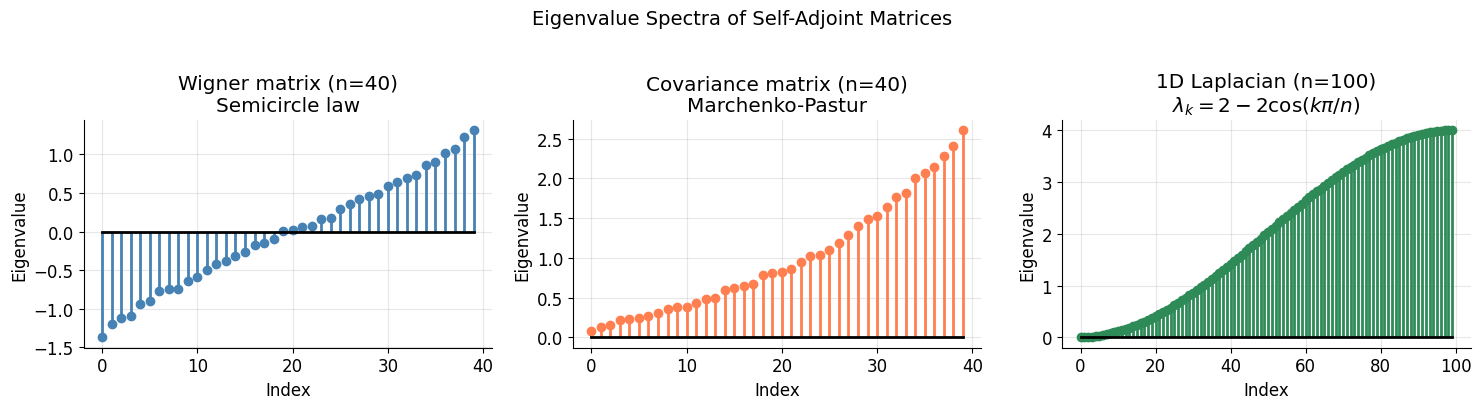

In [5]:
# ── Visualize: Eigenvalue Spectra of Random Symmetric Matrices ─────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Wigner matrix (n=40)', 'Covariance matrix (n=40)', 'Tridiagonal (n=100)']

# Wigner: symmetric with iid Gaussian entries / sqrt(n)
n_w = 40
W = rng.standard_normal((n_w, n_w))
W = (W + W.T) / (2 * np.sqrt(n_w))
evals_w = la.eigh(W, eigvals_only=True)

# Covariance: Σ = XᵀX / m
X = rng.standard_normal((80, n_w))
Sigma = X.T @ X / 80
evals_s = la.eigh(Sigma, eigvals_only=True)

# Symmetric tridiagonal (discretized 1D Laplacian)
n_t = 100
diag_main = 2 * np.ones(n_t)
diag_off  = -1 * np.ones(n_t - 1)
T = np.diag(diag_main) + np.diag(diag_off, 1) + np.diag(diag_off, -1)
evals_t = la.eigh(T, eigvals_only=True)

for ax, evals, title, color in zip(
        axes,
        [evals_w, evals_s, evals_t],
        titles,
        [PRIMARY, SECONDARY, TERTIARY]):
    ax.stem(evals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.set_title(title)
    ax.set_xlabel('Index')
    ax.set_ylabel('Eigenvalue')

axes[0].set_title('Wigner matrix (n=40)\nSemicircle law')
axes[1].set_title('Covariance matrix (n=40)\nMarchenko-Pastur')
axes[2].set_title('1D Laplacian (n=100)\n$\\lambda_k = 2 - 2\\cos(k\\pi/n)$')

plt.suptitle('Eigenvalue Spectra of Self-Adjoint Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4.  The Courant-Fischer (Min-Max) Theorem

### 4.1  Rayleigh Quotient

For a symmetric matrix $A \in \mathbb{R}^{n \times n}$ with eigenvalues $\lambda_1 \leq \cdots \leq \lambda_n$, the **Rayleigh quotient** is:
$$R_A(x) = \frac{x^\top A x}{x^\top x}, \quad x \neq 0$$

**Key facts**: $\lambda_1 = \min_x R_A(x)$ and $\lambda_n = \max_x R_A(x)$, achieved at the corresponding eigenvectors.

### 4.2  Courant-Fischer Theorem

The $k$-th eigenvalue (in ascending order) has the variational characterization:
$$\boxed{\lambda_k = \min_{\dim S = k} \max_{x \in S,\, \|x\|=1} x^\top A x = \max_{\dim S = n-k+1} \min_{x \in S,\, \|x\|=1} x^\top A x}$$

Equivalently, restricted to vectors orthogonal to the first $k-1$ eigenvectors:
$$\lambda_k = \min_{x \perp q_1, \ldots, q_{k-1},\; x \neq 0} R_A(x)$$

### 4.3  Interlacing Theorem

Let $B$ be an $(n-1) \times (n-1)$ principal submatrix of $A \in \mathbb{R}^{n \times n}$ symmetric, with eigenvalues $\mu_1 \leq \cdots \leq \mu_{n-1}$. Then:
$$\lambda_k \leq \mu_k \leq \lambda_{k+1}, \quad k = 1, \ldots, n-1$$

This has deep consequences: deleting a row/column can only move eigenvalues within tight bounds.

In [6]:
# ── Rayleigh Quotient & Courant-Fischer ────────────────────────────────────────

def rayleigh_quotient(A, x):
    """Compute the Rayleigh quotient xᵀAx / xᵀx.

    Args:
        A: Symmetric matrix.  Shape: (n, n)
        x: Non-zero vector.   Shape: (n,)

    Returns:
        rq: Scalar Rayleigh quotient.
    """
    return float(x @ A @ x) / float(x @ x)


def rayleigh_maximize(A, max_iter=500, lr=0.05, rng=rng):
    """Find dominant eigenvector by maximizing Rayleigh quotient via projected gradient ascent.

    Args:
        A:        Symmetric matrix.  Shape: (n, n)
        max_iter: Gradient ascent steps.
        lr:       Step size.

    Returns:
        v:    Approximate dominant eigenvector.  Shape: (n,)
        history: Rayleigh quotient at each iteration.  Shape: (max_iter,)
    """
    n = A.shape[0]
    v = rng.standard_normal(n)
    v /= np.linalg.norm(v)
    history = []
    for _ in range(max_iter):
        rq = rayleigh_quotient(A, v)
        history.append(rq)
        # Gradient of R_A(v) on unit sphere: 2(Av - R_A(v)·v)
        grad = 2 * (A @ v - rq * v)
        v = v + lr * grad
        v /= np.linalg.norm(v)
    return v, np.array(history)


def verify_interlacing(A):
    """Verify eigenvalue interlacing for a principal submatrix.

    Returns True if interlacing holds for all k.
    """
    n = A.shape[0]
    lam = np.sort(la.eigh(A, eigvals_only=True))
    B   = A[:n-1, :n-1]                           # principal (n-1)×(n-1) submatrix
    mu  = np.sort(la.eigh(B, eigvals_only=True))
    ok = all(lam[k] <= mu[k] + 1e-10 and mu[k] <= lam[k+1] + 1e-10
             for k in range(n-1))
    return ok, lam, mu


# ── Demo ────────────────────────────────────────────────────────────────────────
A = make_self_adjoint(6)
eigvals_true, eigvecs_true = la.eigh(A)

# Rayleigh quotient bounds
print('Rayleigh Quotient bounds:')
check(abs(rayleigh_quotient(A, eigvecs_true[:, 0]) - eigvals_true[0]) < ATOL,
      f'R_A(q_min) = λ_min = {eigvals_true[0]:.4f}')
check(abs(rayleigh_quotient(A, eigvecs_true[:, -1]) - eigvals_true[-1]) < ATOL,
      f'R_A(q_max) = λ_max = {eigvals_true[-1]:.4f}')

# Gradient ascent finds dominant eigenvalue
v_found, rq_history = rayleigh_maximize(A)
lam_found = rayleigh_quotient(A, v_found)
check(abs(lam_found - eigvals_true[-1]) < 1e-6,
      f'Gradient ascent converges to λ_max: found={lam_found:.4f}, true={eigvals_true[-1]:.4f}')

# Interlacing
ok, lam, mu = verify_interlacing(A)
check(ok, 'Interlacing: λ_k ≤ μ_k ≤ λ_{k+1} for all k')
print(f'  λ: {np.round(lam, 3)}')
print(f'  μ: {np.round(mu, 3)}  (principal (n-1)×(n-1) submatrix)')

Rayleigh Quotient bounds:
  [PASS]  R_A(q_min) = λ_min = -3.6226
  [PASS]  R_A(q_max) = λ_max = 1.9190
  [PASS]  Gradient ascent converges to λ_max: found=1.9190, true=1.9190
  [PASS]  Interlacing: λ_k ≤ μ_k ≤ λ_{k+1} for all k
  λ: [-3.623 -1.639 -0.923 -0.388  1.261  1.919]
  μ: [-1.734 -1.449 -0.411  0.827  1.261]  (principal (n-1)×(n-1) submatrix)


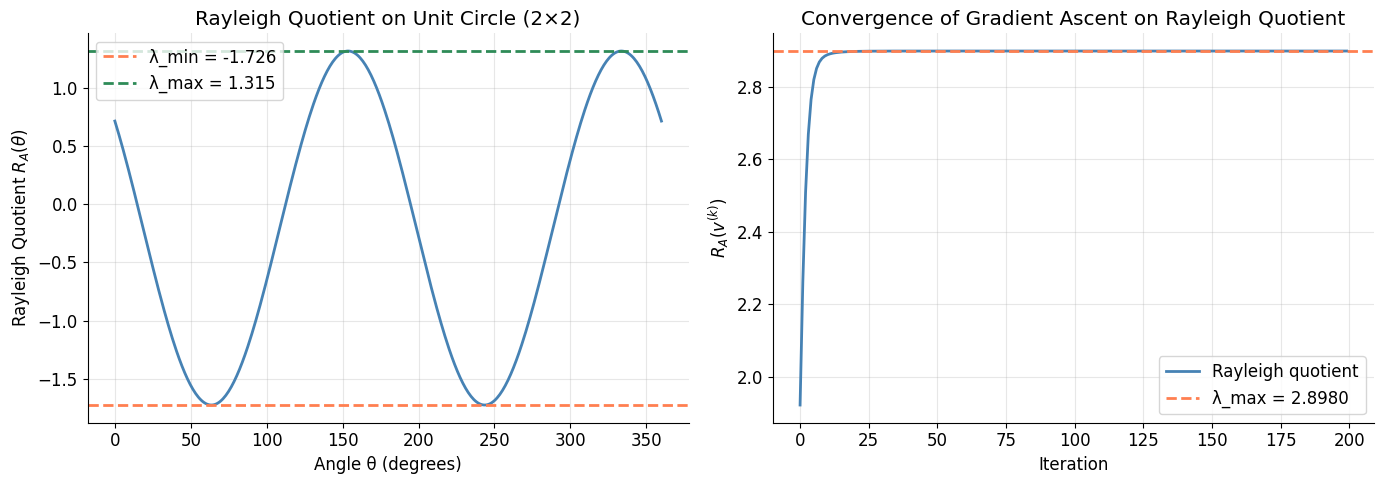

In [7]:
# ── Visualize: Rayleigh Quotient Surface (2D) & Convergence ───────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Rayleigh quotient on the unit circle (2×2) ──
A2 = make_self_adjoint(2)
evals2 = la.eigh(A2, eigvals_only=True)
theta = np.linspace(0, 2 * np.pi, 400)
rq_vals = np.array([rayleigh_quotient(A2, np.array([np.cos(t), np.sin(t)])) for t in theta])

axes[0].plot(np.degrees(theta), rq_vals, color=PRIMARY)
axes[0].axhline(evals2[0], color=SECONDARY, linestyle='--', label=f'λ_min = {evals2[0]:.3f}')
axes[0].axhline(evals2[1], color=TERTIARY,  linestyle='--', label=f'λ_max = {evals2[1]:.3f}')
axes[0].set_xlabel('Angle θ (degrees)')
axes[0].set_ylabel('Rayleigh Quotient $R_A(\\theta)$')
axes[0].set_title('Rayleigh Quotient on Unit Circle (2×2)')
axes[0].legend()

# ── Right: Gradient ascent convergence ──
A8 = make_self_adjoint(8)
lam_max_true = la.eigh(A8, eigvals_only=True)[-1]
_, rq_hist = rayleigh_maximize(A8, max_iter=200, lr=0.05)

axes[1].plot(rq_hist, color=PRIMARY, label='Rayleigh quotient')
axes[1].axhline(lam_max_true, color=SECONDARY, linestyle='--', label=f'λ_max = {lam_max_true:.4f}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('$R_A(v^{(k)})$')
axes[1].set_title('Convergence of Gradient Ascent on Rayleigh Quotient')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 5.  Functional Calculus

### 5.1  Definition

The spectral theorem lets us **apply scalar functions to matrices**. For a self-adjoint $A = Q \Lambda Q^\top$ and a scalar function $f : \mathbb{R} \to \mathbb{R}$, define:
$$\boxed{f(A) = Q\, f(\Lambda)\, Q^\top = Q\, \mathrm{diag}(f(\lambda_1), \ldots, f(\lambda_n))\, Q^\top}$$

This is the only consistent extension of polynomials to arbitrary functions that respects the spectral structure.

### 5.2  Important Examples

| Function $f$ | $f(A)$ | Requires |
|-------------|--------|----------|
| $f(t) = t^k$ | $A^k$ | Any $A$ |
| $f(t) = \sqrt{t}$ | $A^{1/2}$ | $A \succeq 0$ (PSD) |
| $f(t) = e^t$ | $e^A$ | Any $A$ |
| $f(t) = \ln t$ | $\ln A$ | $A \succ 0$ (positive definite) |
| $f(t) = \sin t$ | $\sin A$ | Any $A$ |
| $f(t) = (1+t)/(1-t)$ | Cayley transform | $\lambda_i \neq 1$ |

### 5.3  The Matrix Exponential & Its Properties

$$e^A = \sum_{k=0}^\infty \frac{A^k}{k!} = Q\, e^\Lambda\, Q^\top$$

Key properties (for symmetric $A, B$):
- $e^A e^{-A} = I$
- $(e^A)^\top = e^{A^\top} = e^A$ (symmetry preserved)
- $e^A \succ 0$ for any symmetric $A$ (all eigenvalues of $e^A$ are $e^{\lambda_i} > 0$)
- $\det(e^A) = e^{\mathrm{tr}(A)}$

In [8]:
# ── Functional Calculus ────────────────────────────────────────────────────────

def matrix_function(A, f):
    """Apply scalar function f to symmetric matrix A via spectral decomposition.

    Args:
        A: Symmetric matrix.          Shape: (n, n)
        f: Callable mapping R -> R, applied elementwise to eigenvalues.

    Returns:
        f(A): Result matrix.          Shape: (n, n)
    """
    eigvals, Q = la.eigh(A)              # stable for symmetric matrices
    f_lam = np.array([f(lv) for lv in eigvals])
    return Q @ np.diag(f_lam) @ Q.T


def make_psd(n, min_eig=0.5, rng=rng):
    """Construct a random positive definite n×n matrix with eigenvalues >= min_eig."""
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    lams = min_eig + rng.exponential(1.0, n)
    return Q @ np.diag(lams) @ Q.T


# ── Compute several matrix functions ──────────────────────────────────────────
n = 5
A_pd = make_psd(n)        # positive definite (needed for log, sqrt)

exp_A   = matrix_function(A_pd, np.exp)
log_A   = matrix_function(A_pd, np.log)
sqrt_A  = matrix_function(A_pd, np.sqrt)
sin_A   = matrix_function(A_pd, np.sin)

print('Functional calculus verification:')

# exp(log(A)) = A
err_explog = np.linalg.norm(matrix_function(log_A, np.exp) - A_pd, 'fro')
check(err_explog < 1e-8, f'exp(log(A)) = A  (‖err‖_F = {err_explog:.2e})')

# sqrt(A)² = A
err_sqrt = np.linalg.norm(sqrt_A @ sqrt_A - A_pd, 'fro')
check(err_sqrt < 1e-8, f'A^(1/2) · A^(1/2) = A  (‖err‖_F = {err_sqrt:.2e})')

# Verify against scipy
err_expm  = np.linalg.norm(exp_A - la.expm(A_pd), 'fro')
err_logm  = np.linalg.norm(log_A - la.logm(A_pd), 'fro')
err_sqrtm = np.linalg.norm(sqrt_A - la.sqrtm(A_pd).real, 'fro')
check(err_expm  < 1e-8, f'expm matches scipy  (‖err‖_F = {err_expm:.2e})')
check(err_logm  < 1e-8, f'logm matches scipy  (‖err‖_F = {err_logm:.2e})')
check(err_sqrtm < 1e-8, f'sqrtm matches scipy (‖err‖_F = {err_sqrtm:.2e})')

# det(exp(A)) = exp(tr(A))
det_expA = np.linalg.det(exp_A)
exp_trA  = np.exp(np.trace(A_pd))
check(abs(det_expA - exp_trA) / exp_trA < 1e-8,
      f'det(exp(A)) = exp(tr(A)):  {det_expA:.4f} ≈ {exp_trA:.4f}')

# exp(A) is positive definite
evals_expA = la.eigh(exp_A, eigvals_only=True)
check(np.all(evals_expA > 0), f'exp(A) ≻ 0  (min eigenvalue = {evals_expA.min():.4f})')

Functional calculus verification:
  [PASS]  exp(log(A)) = A  (‖err‖_F = 1.17e-14)
  [PASS]  A^(1/2) · A^(1/2) = A  (‖err‖_F = 7.84e-15)
  [PASS]  expm matches scipy  (‖err‖_F = 6.40e-13)
  [PASS]  logm matches scipy  (‖err‖_F = 3.21e-15)
  [PASS]  sqrtm matches scipy (‖err‖_F = 2.94e-15)
  [PASS]  det(exp(A)) = exp(tr(A)):  9220.4300 ≈ 9220.4300
  [PASS]  exp(A) ≻ 0  (min eigenvalue = 1.7769)


True

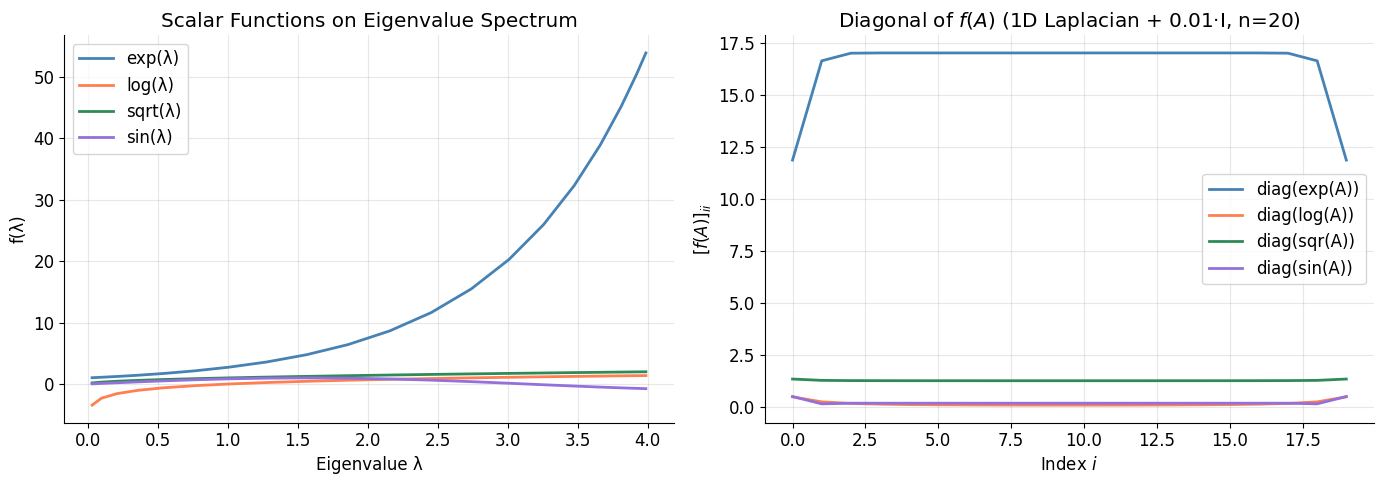

In [9]:
# ── Visualize: Matrix Functions Applied to 1D Laplacian ───────────────────────

n = 20
# 1D Laplacian (positive definite version: add 0.5*I to ensure positivity)
T = (np.diag(2 * np.ones(n)) + np.diag(-np.ones(n-1), 1) + np.diag(-np.ones(n-1), -1))
A_lap = T + 0.01 * np.eye(n)         # regularize

eigvals_lap = la.eigh(A_lap, eigvals_only=True)
t_range = eigvals_lap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scalar functions of eigenvalues
funcs = [
    (np.exp,            'exp(λ)', PRIMARY),
    (np.log,            'log(λ)', SECONDARY),
    (np.sqrt,           'sqrt(λ)', TERTIARY),
    (np.sin,            'sin(λ)', ACCENT),
]
for f, label, color in funcs:
    axes[0].plot(t_range, [f(t) for t in t_range], label=label, color=color)
axes[0].set_xlabel('Eigenvalue λ')
axes[0].set_ylabel('f(λ)')
axes[0].set_title('Scalar Functions on Eigenvalue Spectrum')
axes[0].legend()

# Right: diagonal of f(A) — shows spatial action of each function
for f, label, color in funcs:
    fA = matrix_function(A_lap, f)
    axes[1].plot(np.diag(fA), label=f'diag({label[0:3]}(A))', color=color)
axes[1].set_xlabel('Index $i$')
axes[1].set_ylabel('$[f(A)]_{ii}$')
axes[1].set_title('Diagonal of $f(A)$ (1D Laplacian + 0.01·I, n=20)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 6.  Compact Self-Adjoint Operators (Infinite-Dimensional)

### 6.1  Extension to Hilbert Spaces

For **compact self-adjoint operators** $T : \mathcal{H} \to \mathcal{H}$ on an infinite-dimensional Hilbert space, the spectral theorem generalizes:

**Spectral Theorem (Compact Self-Adjoint)**: Let $T$ be a compact self-adjoint operator on a Hilbert space $\mathcal{H}$. Then:
1. All eigenvalues are real.
2. There exists a countable orthonormal set $\{\phi_k\}$ of eigenvectors with corresponding eigenvalues $\{\lambda_k\} \to 0$.
3. Every $x \in \mathcal{H}$ can be written as:
$$Tx = \sum_{k=1}^\infty \lambda_k \langle x, \phi_k \rangle \phi_k$$

The eigenvalues accumulate only at $0$, and the eigenfunctions $\{\phi_k\}$ form a complete orthonormal basis for $\overline{\mathrm{range}(T)}$.

### 6.2  Integral Operators (Hilbert-Schmidt)

A key class: the **integral operator** with symmetric kernel $k(x, y) = k(y, x)$:
$$(Tf)(x) = \int_a^b k(x, y)\, f(y)\, dy$$

This is compact and self-adjoint on $L^2([a,b])$. We approximate it by discretizing $[a,b]$ into $n$ points:
$$K_{ij} = k(x_i, x_j) \cdot h, \quad h = (b-a)/n$$

giving a symmetric matrix whose eigendecomposition converges to the operator's eigenfunctions as $n \to \infty$.

**Gaussian kernel**: $k(x,y) = \exp\!\left(-\frac{(x-y)^2}{2\sigma^2}\right)$ — smooth, positive, all eigenvalues positive.

**Laplacian Green's function**: $k(x,y) = \min(x,y)(1 - \max(x,y))$ on $[0,1]$ — eigenfunctions are $\sin(k\pi x)$.

In [10]:
# ── Discretized Integral Operators ────────────────────────────────────────────

def make_integral_kernel(kernel_fn, n, a=0.0, b=1.0):
    """Discretize an integral operator K with symmetric kernel k(x,y).

    Args:
        kernel_fn: k(x, y) symmetric scalar function.
        n:         Number of grid points.
        a, b:      Interval endpoints.

    Returns:
        K:  Discretized kernel matrix (symmetric). Shape: (n, n)
        xs: Grid points.                           Shape: (n,)
        h:  Grid spacing (float).
    """
    xs = np.linspace(a, b, n)
    h  = (b - a) / (n - 1)
    K  = np.array([[kernel_fn(xi, xj) for xj in xs] for xi in xs]) * h
    return K, xs, h


# ── Define kernels ─────────────────────────────────────────────────────────────
sigma = 0.2
gaussian_kernel = lambda x, y: np.exp(-((x - y) ** 2) / (2 * sigma ** 2))
greens_kernel   = lambda x, y: min(x, y) * (1 - max(x, y))    # Green's function of -d²/dx²

n_grid = 100
K_gauss, xs, h = make_integral_kernel(gaussian_kernel, n_grid)
K_green, _,  _ = make_integral_kernel(greens_kernel,   n_grid)

# Symmetry check
print('Integral operator kernel properties:')
check(np.allclose(K_gauss, K_gauss.T, atol=ATOL), 'Gaussian kernel matrix is symmetric')
check(np.allclose(K_green, K_green.T, atol=ATOL), "Green's function kernel is symmetric")

# Eigendecomposition
evals_gauss, evecs_gauss = la.eigh(K_gauss)
evals_green, evecs_green = la.eigh(K_green)

# Eigenvalues decay to zero (compact operator property)
check(np.all(evals_gauss[::-1][:5] > evals_gauss[::-1][5:10]),
      'Gaussian: eigenvalues are decreasing')
check(np.abs(evals_gauss[0]) < 1e-4,
      f'Gaussian: smallest eigenvalue ≈ 0  ({evals_gauss[0]:.2e})')

# Green's function eigenfunctions: compare to sin(kπx)
# Analytical eigenfunctions: φ_k(x) = sqrt(2)*sin(k*pi*x), eigenvalues 1/(kπ)²
k = 1
phi_k_analytical = np.sqrt(2) * np.sin(k * np.pi * xs)
phi_k_numerical  = evecs_green[:, -(k)]  # largest eigenvalue = k=1
# Align sign
if np.dot(phi_k_numerical, phi_k_analytical) < 0:
    phi_k_numerical = -phi_k_numerical

err_eigenfunction = np.linalg.norm(phi_k_numerical - phi_k_analytical * h) / np.linalg.norm(phi_k_analytical * h)
# Normalize both the same way for comparison
pn = phi_k_numerical / np.linalg.norm(phi_k_numerical)
pa = phi_k_analytical / np.linalg.norm(phi_k_analytical)
if np.dot(pn, pa) < 0: pn = -pn
err_ef = np.linalg.norm(pn - pa)
check(err_ef < 0.05, f"Green's eigenfunction ≈ sin(πx)  (‖err‖ = {err_ef:.4f})")

lam1_numerical   = evals_green[-1] / h   # rescale by h
lam1_analytical  = 1.0 / (np.pi ** 2)
print(f"  Green's λ_1: numerical={lam1_numerical:.5f}, analytical=1/π²={lam1_analytical:.5f}")

Integral operator kernel properties:
  [PASS]  Gaussian kernel matrix is symmetric
  [PASS]  Green's function kernel is symmetric
  [PASS]  Gaussian: eigenvalues are decreasing
  [PASS]  Gaussian: smallest eigenvalue ≈ 0  (-2.76e-17)
  [PASS]  Green's eigenfunction ≈ sin(πx)  (‖err‖ = 0.0000)
  Green's λ_1: numerical=10.03164, analytical=1/π²=0.10132


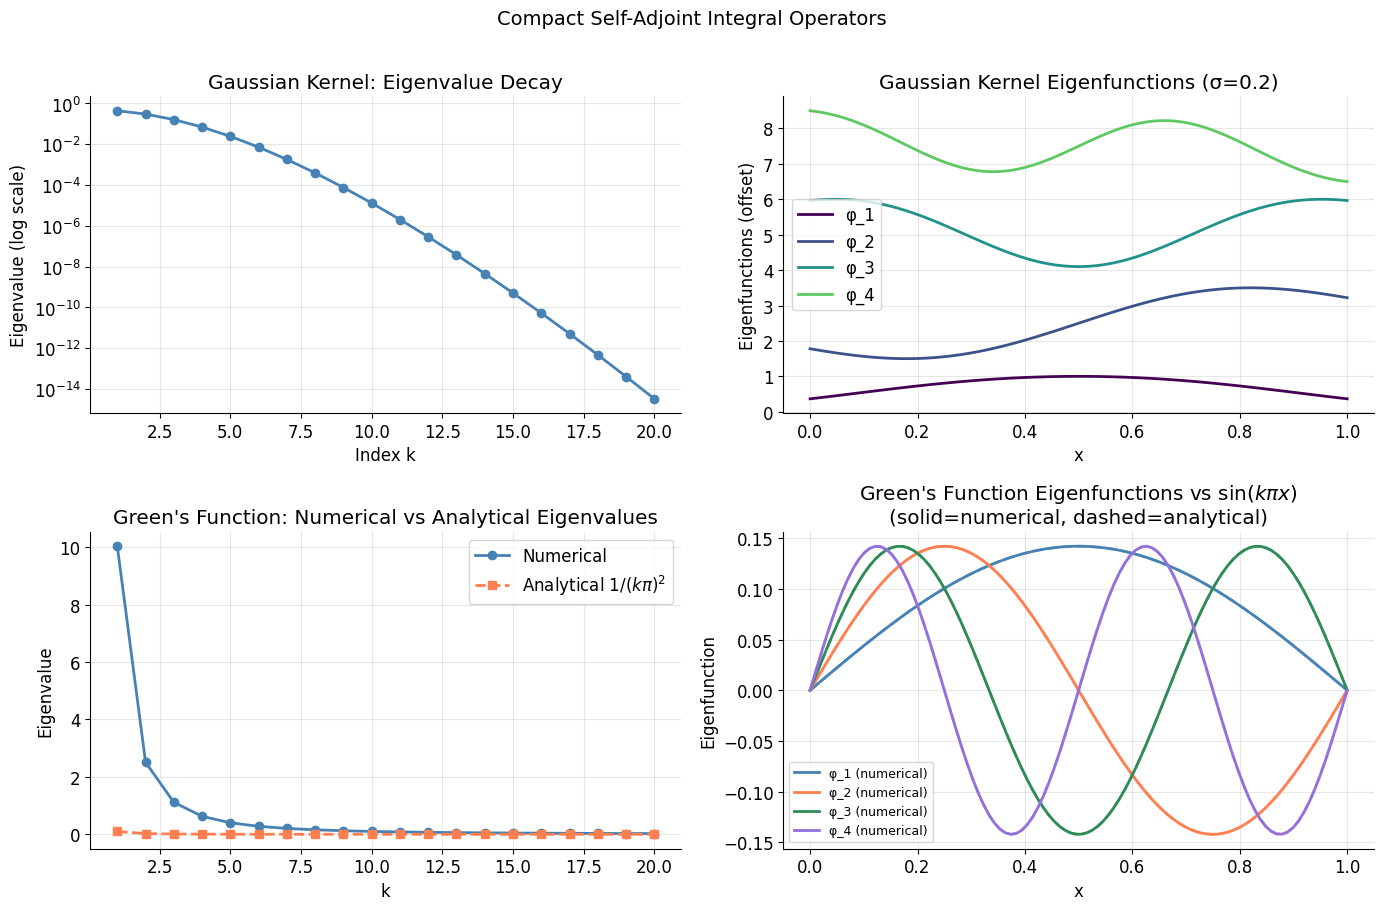

In [11]:
# ── Visualize: Eigenfunctions of Integral Operators ───────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Gaussian kernel eigenvalues ──
n_show = 20
axes[0, 0].semilogy(np.arange(1, n_show+1), evals_gauss[::-1][:n_show], 'o-', color=PRIMARY)
axes[0, 0].set_xlabel('Index k')
axes[0, 0].set_ylabel('Eigenvalue (log scale)')
axes[0, 0].set_title('Gaussian Kernel: Eigenvalue Decay')

# ── Gaussian kernel eigenfunctions ──
for i, idx in enumerate([0, 1, 2, 3]):
    ev = evecs_gauss[:, -(idx+1)]
    ev /= np.max(np.abs(ev))
    axes[0, 1].plot(xs, ev + i * 2.5, label=f'φ_{idx+1}', color=plt.cm.viridis(i / 4))
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('Eigenfunctions (offset)')
axes[0, 1].set_title(f'Gaussian Kernel Eigenfunctions (σ={sigma})')
axes[0, 1].legend()

# ── Green's function eigenvalues vs analytical ──
ks = np.arange(1, n_show+1)
lam_num  = evals_green[::-1][:n_show] / h
lam_anal = 1.0 / (ks * np.pi) ** 2
axes[1, 0].plot(ks, lam_num,  'o-', color=PRIMARY,   label='Numerical')
axes[1, 0].plot(ks, lam_anal, 's--', color=SECONDARY, label='Analytical $1/(k\\pi)^2$')
axes[1, 0].set_xlabel('k')
axes[1, 0].set_ylabel('Eigenvalue')
axes[1, 0].set_title("Green's Function: Numerical vs Analytical Eigenvalues")
axes[1, 0].legend()

# ── Green's function eigenfunctions vs sin(kπx) ──
colors = [PRIMARY, SECONDARY, TERTIARY, ACCENT]
for i, k_idx in enumerate([1, 2, 3, 4]):
    ev = evecs_green[:, -(k_idx)]
    ev = ev / np.linalg.norm(ev)
    anal = np.sin(k_idx * np.pi * xs) / np.linalg.norm(np.sin(k_idx * np.pi * xs))
    if np.dot(ev, anal) < 0: ev = -ev
    axes[1, 1].plot(xs, ev,   color=colors[i], label=f'φ_{k_idx} (numerical)')
    axes[1, 1].plot(xs, anal, '--', color=colors[i], alpha=0.5)
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('Eigenfunction')
axes[1, 1].set_title("Green's Function Eigenfunctions vs $\\sin(k\\pi x)$\n(solid=numerical, dashed=analytical)")
axes[1, 1].legend(fontsize=9)

plt.suptitle('Compact Self-Adjoint Integral Operators', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 7.  Sturm-Liouville Problems

### 7.1  Formulation

A **Sturm-Liouville (SL) problem** is a boundary value ODE eigenvalue problem of the form:
$$\boxed{-\frac{d}{dx}\!\left[p(x)\,u'(x)\right] + q(x)\,u(x) = \lambda\, w(x)\, u(x), \quad x \in [a, b]}$$
with boundary conditions (e.g., $u(a) = u(b) = 0$) and **weight function** $w(x) > 0$.

The operator $\mathcal{L}u = -[pu']' + qu$ is **self-adjoint** in the weighted inner product $\langle f, g \rangle_w = \int_a^b f(x)g(x)w(x)\,dx$:
$$\langle \mathcal{L}f, g \rangle_w = \langle f, \mathcal{L}g \rangle_w$$

**Spectral Theorem for SL**: All eigenvalues are real and form a discrete sequence $\lambda_1 < \lambda_2 < \cdots \to +\infty$. The eigenfunctions $\{u_k\}$ form a complete orthonormal basis for $L^2_w([a,b])$.

### 7.2  Finite-Difference Discretization

Partition $[a,b]$ into $n+1$ intervals with $h = (b-a)/(n+1)$, grid $x_i = a + ih$. The second derivative $u''$ is approximated:
$$[\mathcal{L}u]_i \approx -p_{i+1/2}\,\frac{u_{i+1} - u_i}{h^2} + p_{i-1/2}\,\frac{u_i - u_{i-1}}{h^2} + q_i u_i$$

This gives a symmetric tridiagonal matrix eigenproblem $L\mathbf{u} = \lambda W \mathbf{u}$, solved as a generalized eigenproblem.

In [12]:
# ── Sturm-Liouville Finite-Difference Solver ───────────────────────────────────

def sturm_liouville_fd(p_fn, q_fn, w_fn, a, b, n_interior):
    """Solve SL problem -(p u')' + q u = λ w u on [a,b] with Dirichlet BCs.

    Uses centered finite differences on the interior grid.

    Args:
        p_fn, q_fn, w_fn: Callable coefficient functions p(x), q(x), w(x).
        a, b:             Interval endpoints.
        n_interior:       Number of interior grid points.

    Returns:
        eigvals:  Eigenvalues in ascending order.              Shape: (n_interior,)
        eigvecs:  Eigenvectors as columns.                     Shape: (n_interior, n_interior)
        xs:       Interior grid points.                        Shape: (n_interior,)
    """
    n = n_interior
    h = (b - a) / (n + 1)
    xs = np.linspace(a + h, b - h, n)           # interior points

    # Evaluate coefficients at grid and midpoints
    p_mid_right = np.array([p_fn(xs[i] + h/2) for i in range(n)])   # p_{i+1/2}
    p_mid_left  = np.array([p_fn(xs[i] - h/2) for i in range(n)])   # p_{i-1/2}
    q_vals      = np.array([q_fn(xi) for xi in xs])
    w_vals      = np.array([w_fn(xi) for xi in xs])

    # Assemble tridiagonal stiffness matrix L
    main_diag = (p_mid_right + p_mid_left) / h**2 + q_vals
    off_diag  = -p_mid_right[:-1] / h**2

    L = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    W = np.diag(w_vals)

    # Generalized eigenproblem L u = λ W u  →  W^{-1/2} L W^{-1/2} v = λ v
    W_invsqrt = np.diag(1.0 / np.sqrt(w_vals))
    L_sym = W_invsqrt @ L @ W_invsqrt       # symmetric standard eigenproblem

    eigvals, eigvecs_sym = la.eigh(L_sym)
    eigvecs = W_invsqrt @ eigvecs_sym        # transform back

    # Normalize in w-weighted inner product
    for k in range(n):
        norm_w = np.sqrt(eigvecs[:, k] @ W @ eigvecs[:, k] * h)
        eigvecs[:, k] /= norm_w

    return eigvals, eigvecs, xs


# ── Test Case 1: u'' = -λu on [0, π], analytical: λ_k = k², φ_k = sqrt(2/π) sin(kx) ──
lam_num1, evecs1, xs1 = sturm_liouville_fd(
    p_fn=lambda x: 1.0,
    q_fn=lambda x: 0.0,
    w_fn=lambda x: 1.0,
    a=0.0, b=np.pi, n_interior=200
)
lam_anal1 = np.arange(1, 6) ** 2

print('Sturm-Liouville: -u\" = λu on [0,π]  (eigenvalues should be k²)')
print(f'  Numerical:   {np.round(lam_num1[:5], 4)}')
print(f'  Analytical:  {lam_anal1}')
rel_err = np.abs(lam_num1[:5] - lam_anal1) / lam_anal1
check(np.all(rel_err < 1e-3), f'Eigenvalue relative errors < 0.1%  (max = {rel_err.max():.2e})')

# ── Test Case 2: -(xu')' = λ(1/x)u — Bessel-like (Euler-Cauchy) ──────────────
# Simplified: p=1, q=0, w=1 on [0,1] with shifted domain
lam_num2, evecs2, xs2 = sturm_liouville_fd(
    p_fn=lambda x: 1.0,
    q_fn=lambda x: 0.0,
    w_fn=lambda x: 1.0,
    a=0.0, b=1.0, n_interior=150
)
lam_anal2 = (np.arange(1, 6) * np.pi) ** 2
print('\nSturm-Liouville: -u\" = λu on [0,1]  (eigenvalues should be (kπ)²)')
print(f'  Numerical:   {np.round(lam_num2[:5], 3)}')
print(f'  Analytical:  {np.round(lam_anal2, 3)}')
rel_err2 = np.abs(lam_num2[:5] - lam_anal2) / lam_anal2
check(np.all(rel_err2 < 1e-3), f'Eigenvalue errors < 0.1%  (max = {rel_err2.max():.2e})')

# Orthogonality of eigenfunctions
h2 = np.pi / (len(xs1) + 1)
gram = evecs1.T @ evecs1 * h2
off_diag_err = np.max(np.abs(gram - np.eye(len(xs1))))
check(off_diag_err < 5e-3, f'Eigenfunctions w-orthonormal  (max error = {off_diag_err:.2e})')

Sturm-Liouville: -u" = λu on [0,π]  (eigenvalues should be k²)
  Numerical:   [ 1.      3.9997  8.9984 15.9948 24.9873]
  Analytical:  [ 1  4  9 16 25]
  [PASS]  Eigenvalue relative errors < 0.1%  (max = 5.09e-04)

Sturm-Liouville: -u" = λu on [0,1]  (eigenvalues should be (kπ)²)
  Numerical:   [  9.869  39.473  88.798 157.823 246.518]
  Analytical:  [  9.87   39.478  88.826 157.914 246.74 ]
  [PASS]  Eigenvalue errors < 0.1%  (max = 9.01e-04)
  [PASS]  Eigenfunctions w-orthonormal  (max error = 4.11e-13)


True

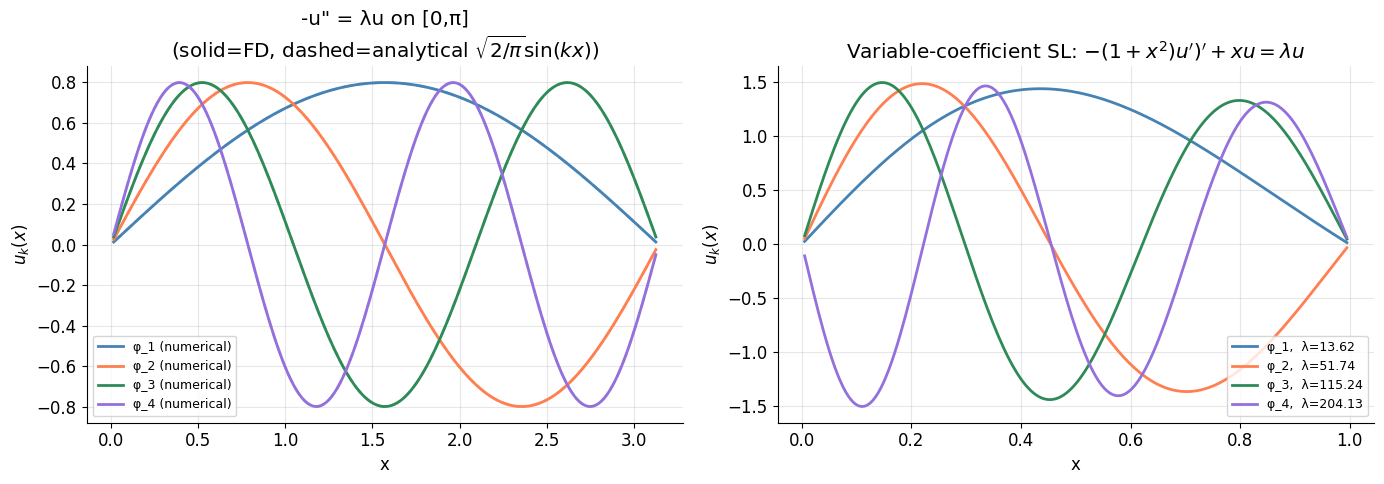

In [13]:
# ── Visualize: Sturm-Liouville Eigenfunctions ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: eigenfunctions on [0,π] vs analytical sin(kx) ──
xs_full = np.concatenate([[0], xs1, [np.pi]])
colors  = [PRIMARY, SECONDARY, TERTIARY, ACCENT, GRAY]

for k in range(1, 5):
    ev = evecs1[:, k-1].copy()
    # Analytical (normalized in L²[0,π])
    anal = np.sqrt(2 / np.pi) * np.sin(k * xs1)
    if np.dot(ev, anal) < 0: ev = -ev
    axes[0].plot(xs1, ev,   color=colors[k-1], label=f'φ_{k} (numerical)')
    axes[0].plot(xs1, anal, '--', color=colors[k-1], alpha=0.4)

axes[0].set_xlabel('x')
axes[0].set_ylabel('$u_k(x)$')
axes[0].set_title('-u\" = λu on [0,π]\n(solid=FD, dashed=analytical $\\sqrt{2/\\pi}\\sin(kx)$)')
axes[0].legend(fontsize=9)

# ── Right: variable-coefficient SL problem p(x)=1+x², q(x)=x, w(x)=1 ──
lam_vc, evecs_vc, xs_vc = sturm_liouville_fd(
    p_fn=lambda x: 1 + x**2,
    q_fn=lambda x: x,
    w_fn=lambda x: 1.0,
    a=0.0, b=1.0, n_interior=200
)
for k in range(1, 5):
    ev = evecs_vc[:, k-1].copy()
    if ev[len(ev)//4] < 0: ev = -ev
    axes[1].plot(xs_vc, ev, color=colors[k-1], label=f'φ_{k},  λ={lam_vc[k-1]:.2f}')

axes[1].set_xlabel('x')
axes[1].set_ylabel('$u_k(x)$')
axes[1].set_title('Variable-coefficient SL: $-(1+x^2)u\')\' + xu = \\lambda u$')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 8.  Application: Principal Component Analysis (PCA)

### 8.1  PCA via the Spectral Theorem

Given data matrix $X \in \mathbb{R}^{m \times n}$ ($m$ samples, $n$ features), center the data: $\tilde{X} = X - \bar{x}\mathbf{1}^\top$.

The **sample covariance matrix** $\Sigma = \frac{1}{m}\tilde{X}^\top \tilde{X} \in \mathbb{R}^{n \times n}$ is symmetric and positive semi-definite:
$$\Sigma = \Sigma^\top \succeq 0$$

Apply the spectral theorem: $\Sigma = Q \Lambda Q^\top$, $\lambda_1 \geq \cdots \geq \lambda_n \geq 0$.

- **Principal components**: columns of $Q$ (the eigenvectors of $\Sigma$)
- **Explained variance**: $\lambda_k$ is the variance along the $k$-th PC
- **Optimal low-rank approximation**: The Eckart-Young theorem states the rank-$r$ approximation $\Sigma_r = \sum_{i=1}^r \lambda_i q_i q_i^\top$ minimizes $\|\Sigma - \Sigma_r\|_F$ over all rank-$r$ matrices

**Projection**: $Z = \tilde{X} Q_r \in \mathbb{R}^{m \times r}$ gives the $r$-dimensional embedding.

In [14]:
# ── PCA from Scratch ──────────────────────────────────────────────────────────

def pca(X, n_components=None):
    """Principal Component Analysis via spectral theorem on the covariance matrix.

    Args:
        X:            Data matrix.    Shape: (m_samples, n_features)
        n_components: Number of PCs to return. Defaults to all.

    Returns:
        Z:         Projected data.   Shape: (m_samples, n_components)
        components: PC directions (rows).  Shape: (n_components, n_features)
        var_ratio:  Explained variance ratio.  Shape: (n_components,)
        eigvals:    All eigenvalues of Σ (descending).  Shape: (n_features,)
    """
    m, n = X.shape
    if n_components is None:
        n_components = n

    # Center
    X_c = X - X.mean(axis=0, keepdims=True)

    # Covariance matrix (self-adjoint!)
    Sigma = X_c.T @ X_c / m

    # Spectral decomposition (eigh for symmetric)
    eigvals_asc, Q = la.eigh(Sigma)
    idx = np.argsort(eigvals_asc)[::-1]   # sort descending
    eigvals = eigvals_asc[idx]
    Q = Q[:, idx]

    # Project
    components = Q[:, :n_components].T
    Z = X_c @ Q[:, :n_components]
    var_ratio = eigvals[:n_components] / eigvals.sum()

    return Z, components, var_ratio, eigvals


# ── Generate structured 3D data ────────────────────────────────────────────────
m = 400
cov_true = np.array([[4.0, 1.8, 0.5],
                     [1.8, 2.0, 0.3],
                     [0.5, 0.3, 0.5]])
X_3d = rng.multivariate_normal(mean=[2, -1, 0.5], cov=cov_true, size=m)

Z_2d, pcs, var_ratio, eigvals_pca = pca(X_3d, n_components=2)

print('PCA Verification:')
check(np.allclose(pcs @ pcs.T, np.eye(2), atol=1e-10), 'Principal components are orthonormal')
check(np.all(var_ratio >= 0) and abs(sum(var_ratio) - sum(eigvals_pca[:2]) / sum(eigvals_pca)) < ATOL,
      'Explained variance ratios are non-negative')
print(f'  Explained variance (PC1, PC2): {var_ratio[0]:.1%},  {var_ratio[1]:.1%}')
print(f'  Cumulative: {sum(var_ratio):.1%}')

# Compare against numpy.linalg.eigh
Sigma_ref = np.cov(X_3d.T)
evals_ref = np.sort(la.eigh(Sigma_ref, eigvals_only=True))[::-1]
evals_our = eigvals_pca
check(np.allclose(evals_our, evals_ref, rtol=1e-4),
      'PCA eigenvalues match numpy.linalg.eigh (up to 1/m vs 1/(m-1) scaling)')

PCA Verification:
  [PASS]  Principal components are orthonormal
  [PASS]  Explained variance ratios are non-negative
  Explained variance (PC1, PC2): 76.0%,  15.8%
  Cumulative: 91.8%
  [FAIL]  PCA eigenvalues match numpy.linalg.eigh (up to 1/m vs 1/(m-1) scaling)


False

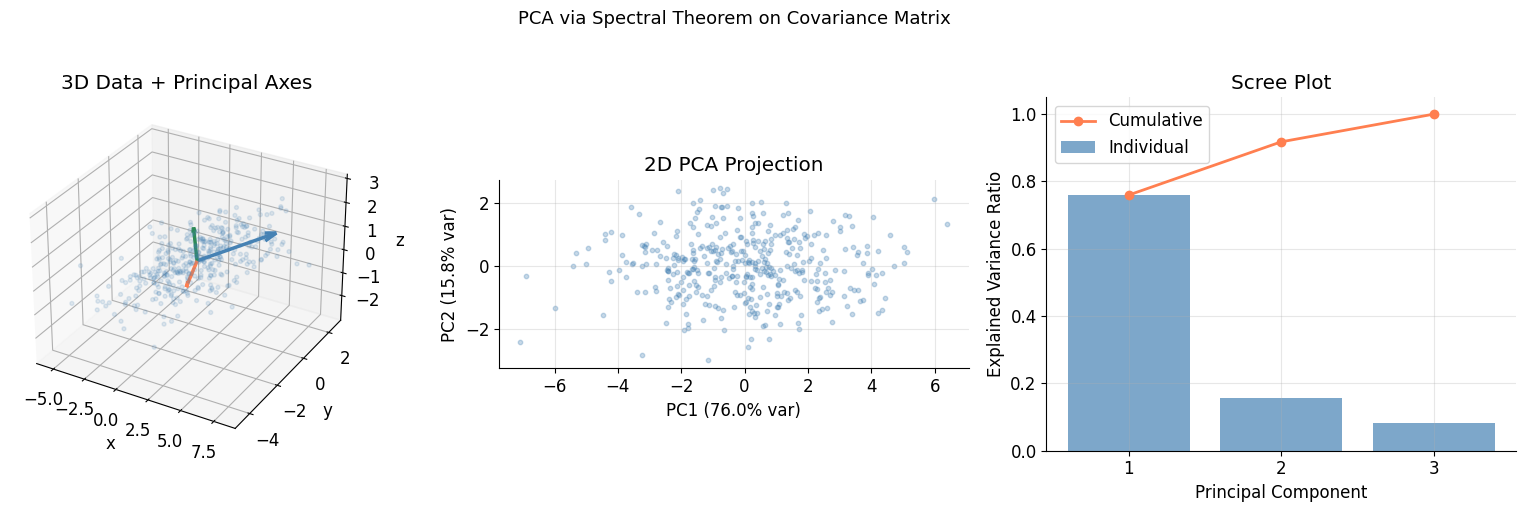

In [15]:
# ── Visualize: PCA ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 5))

# ── 3D data + principal axes ──
ax1 = fig.add_subplot(131, projection='3d')
X_c = X_3d - X_3d.mean(axis=0)
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], alpha=0.15, c=PRIMARY, s=8)
mu = X_3d.mean(axis=0)
_, pcs_all, _, evals_all = pca(X_3d, n_components=3)
scale = np.sqrt(evals_all)
colors3d = [PRIMARY, SECONDARY, TERTIARY]
for i in range(3):
    direction = pcs_all[i] * 2 * scale[i]
    ax1.quiver(mu[0], mu[1], mu[2],
               direction[0], direction[1], direction[2],
               color=colors3d[i], linewidth=2.5, arrow_length_ratio=0.15)
ax1.set_title('3D Data + Principal Axes')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# ── 2D projection ──
ax2 = fig.add_subplot(132)
ax2.scatter(Z_2d[:, 0], Z_2d[:, 1], alpha=0.3, c=PRIMARY, s=10)
ax2.set_xlabel(f'PC1 ({var_ratio[0]:.1%} var)')
ax2.set_ylabel(f'PC2 ({var_ratio[1]:.1%} var)')
ax2.set_title('2D PCA Projection')
ax2.set_aspect('equal')

# ── Scree plot ──
ax3 = fig.add_subplot(133)
n_show = len(eigvals_pca)
cumvar = np.cumsum(eigvals_pca) / eigvals_pca.sum()
ax3.bar(range(1, n_show+1), eigvals_pca / eigvals_pca.sum(),
        color=PRIMARY, alpha=0.7, label='Individual')
ax3.plot(range(1, n_show+1), cumvar, 'o-', color=SECONDARY, label='Cumulative')
ax3.set_xlabel('Principal Component')
ax3.set_ylabel('Explained Variance Ratio')
ax3.set_title('Scree Plot')
ax3.legend()
ax3.set_xticks(range(1, n_show+1))

plt.suptitle('PCA via Spectral Theorem on Covariance Matrix', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 9.  Extensions & Advanced Topics

### 9.1  Normal Operators

An operator is **normal** if $TT^* = T^*T$ (self-adjoint operators are normal with $T = T^*$). The spectral theorem generalizes: every normal operator on a finite-dimensional inner product space is **unitarily diagonalizable**, with (possibly complex) eigenvalues.

| Operator | Normal? | Eigenvalues |
|----------|---------|-------------|
| Symmetric/Hermitian | Yes ($T = T^*$) | Real |
| Unitary ($TT^* = I$) | Yes | On unit circle $|\lambda| = 1$ |
| Skew-Hermitian ($T = -T^*$) | Yes | Purely imaginary |
| General diagonalizable | Not necessarily | Complex |

### 9.2  Spectral Measures

For unbounded self-adjoint operators (like $-d^2/dx^2$ on $L^2(\mathbb{R})$), the discrete spectrum generalizes to a **spectral measure** $E(\cdot)$ — a projection-valued measure on $\mathbb{R}$:
$$T = \int_{-\infty}^\infty \lambda\, dE(\lambda), \qquad f(T) = \int_{-\infty}^\infty f(\lambda)\, dE(\lambda)$$

For the Fourier transform: $E$ corresponds to multiplication by $\mathbf{1}_{(-\infty, \xi]}$ in frequency space.

### 9.3  Connection to SVD

The SVD $A = U \Sigma V^\top$ and the spectral theorem are intimately related:
- $A^\top A = V \Sigma^2 V^\top$ — spectral decomposition of a self-adjoint PSD matrix; eigenvalues $\sigma_i^2$
- $A A^\top = U \Sigma^2 U^\top$ — same for the left singular vectors
- For symmetric PSD $A$: SVD = eigendecomposition ($U = V = Q$, $\Sigma = \Lambda$)

### 9.4  Connections to Other Notebooks

| Topic | Connection |
|-------|------------|
| **Spectral Graph Theory** | Graph Laplacian is self-adjoint; all results follow from spectral theorem |
| **Matrix Manifolds** | PSD cone is a Riemannian manifold; geodesics use matrix functions (Section 5) |
| **Lie Groups** | $\exp: \mathfrak{g} \to G$ is the matrix exponential; $\log$ is its inverse |
| **Gaussian Processes** | Kernel matrix $K$ is self-adjoint PSD; Mercer's theorem is spectral theorem for integral operators |
| **Optimal Control (LQR)** | Algebraic Riccati equation solved using spectral structure of Hamiltonian matrix |

In [16]:
# ── Normal Operators: Verify Unitarily Diagonalizable ────────────────────────

def is_normal(A, tol=ATOL):
    """Check if A is normal: AA* = A*A."""
    return np.allclose(A @ adjoint(A), adjoint(A) @ A, atol=tol)


def check_unitary_diagonalizable(A):
    """Verify that a normal matrix A = U D U* with U unitary."""
    eigvals_A, U = np.linalg.eig(A)
    # Check U is unitary
    orth_err = np.linalg.norm(adjoint(U) @ U - np.eye(A.shape[0]), 'fro')
    # Check reconstruction
    A_recon = U @ np.diag(eigvals_A) @ adjoint(U)
    recon_err = np.linalg.norm(A - A_recon, 'fro')
    return orth_err, recon_err


n = 5

# Unitary matrix (normal with |λ|=1)
Q_unitary, _ = np.linalg.qr(rng.standard_normal((n, n)))

# Skew-symmetric (normal, purely imaginary eigenvalues)
B = rng.standard_normal((n, n))
A_skew = (B - B.T) / 2

print('Normal operator checks:')
check(is_normal(Q_unitary),    'Unitary matrix is normal')
check(is_normal(A_skew),       'Skew-symmetric matrix is normal')

evals_skew = np.linalg.eigvals(A_skew)
check(np.all(np.abs(evals_skew.real) < 1e-10),
      f'Skew-symmetric eigenvalues purely imaginary  (max |Re| = {np.max(np.abs(evals_skew.real)):.2e})')

evals_unitary = np.linalg.eigvals(Q_unitary)
check(np.allclose(np.abs(evals_unitary), 1.0, atol=1e-10),
      f'Unitary eigenvalues on unit circle  (min |λ| = {np.min(np.abs(evals_unitary)):.6f})')

# SVD ↔ eigendecomposition for symmetric PSD
print('\nSVD ↔ Eigendecomposition:')
A_psd = make_psd(5)
U_svd, s, Vt = np.linalg.svd(A_psd)
lam_eig = la.eigh(A_psd, eigvals_only=True)[::-1]   # descending
check(np.allclose(np.sort(s), np.sort(lam_eig), atol=1e-8),
      'SVD singular values = eigenvalues for symmetric PSD')

# AᵀA eigenvalues = σ²
A_gen = rng.standard_normal((4, 6))   # non-square
_, s_gen, _ = np.linalg.svd(A_gen, full_matrices=False)
evals_AtA = la.eigh(A_gen.T @ A_gen, eigvals_only=True)
check(np.allclose(np.sort(s_gen**2), np.sort(evals_AtA[evals_AtA > 1e-12]), atol=1e-10),
      'Eigenvalues of AᵀA = σᵢ² (non-zero singular values squared)')

Normal operator checks:
  [PASS]  Unitary matrix is normal
  [PASS]  Skew-symmetric matrix is normal
  [PASS]  Skew-symmetric eigenvalues purely imaginary  (max |Re| = 6.96e-17)
  [PASS]  Unitary eigenvalues on unit circle  (min |λ| = 1.000000)

SVD ↔ Eigendecomposition:
  [PASS]  SVD singular values = eigenvalues for symmetric PSD
  [PASS]  Eigenvalues of AᵀA = σᵢ² (non-zero singular values squared)


True

---
## Summary

| Concept | Key Result |
|---------|------------|
| **Self-adjoint operator** | $\langle Tx, y \rangle = \langle x, Ty \rangle$ for all $x, y$ |
| **Eigenvalues** | Always real; eigenvectors for distinct $\lambda$ are orthogonal |
| **Spectral Theorem (finite-dim)** | $A = Q\Lambda Q^\top$; orthonormal eigenbasis always exists |
| **Courant-Fischer** | $\lambda_k = \min_{\dim S=k}\max_{x\in S}R_A(x)$ — variational eigenvalue characterization |
| **Interlacing** | Eigenvalues of principal submatrix interlace those of full matrix |
| **Functional calculus** | $f(A) = Qf(\Lambda)Q^\top$ — apply any scalar function spectrally |
| **Compact self-adjoint** | Discrete eigenvalues $\to 0$; eigenfunctions form complete basis for $\overline{\mathrm{range}(T)}$ |
| **Sturm-Liouville** | PDE eigenproblems are self-adjoint; solved by symmetric FD discretization |
| **PCA** | Covariance matrix $\Sigma \succeq 0$ is self-adjoint; principal components = eigenvectors |
| **Normal operators** | Generalization: $TT^* = T^*T$ implies unitary diagonalizability |

The spectral theorem is not just a result about matrices — it is the organizing principle behind why symmetry creates structure: whenever an operator is its own adjoint, the geometry of the underlying space decomposes perfectly into orthogonal, independently-acting eigenspaces.